# 01_eda_overview

## Df preparing

In [135]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from IPython.display import display
from sympy import false

np.random.seed(42)
RAW_DIR = "../data/raw"

Upload all tables (except for sample submission, as it is not needed at this stage)

In [178]:
air_reserve_df = pd.read_csv(RAW_DIR + "/air_reserve.csv")
air_store_df = pd.read_csv(RAW_DIR + "/air_store_info.csv")
air_visit_df = pd.read_csv(RAW_DIR + "/air_visit_data.csv")

hpg_reserve_df = pd.read_csv(RAW_DIR + "/hpg_reserve.csv")
hpg_store_df = pd.read_csv(RAW_DIR + "/hpg_store_info.csv")

date_info_df = pd.read_csv(RAW_DIR + "/date_info.csv")
store_id_rel_df = pd.read_csv(RAW_DIR + "/store_id_relation.csv")

Next, need to designate the indexes and convert the dates to the required format.

In [179]:
air_reserve_df["visit_datetime"] = pd.to_datetime(air_reserve_df["visit_datetime"])
air_reserve_df["reserve_datetime"] = pd.to_datetime(air_reserve_df["reserve_datetime"])

air_visit_df["visit_date"] = pd.to_datetime(air_visit_df["visit_date"])

date_info_df["calendar_date"] = pd.to_datetime(date_info_df["calendar_date"])

hpg_reserve_df["visit_datetime"] = pd.to_datetime(hpg_reserve_df["visit_datetime"])
hpg_reserve_df["reserve_datetime"] = pd.to_datetime(hpg_reserve_df["reserve_datetime"])

Let"s determine the number of unique air_store_id"s that exist in the corresponding tables.

In [180]:
air_reserve_unique_store_ids = set(air_reserve_df["air_store_id"].unique())
air_visit_unique_store_ids = set(air_visit_df["air_store_id"].unique())
air_store_unique_store_ids = set(air_store_df["air_store_id"].unique())

print(f"Air reserve unique store ids: {len(air_reserve_unique_store_ids)}")
print(f"Air visit unique store ids: {len(air_visit_unique_store_ids)}")
print(f"Air store unique store ids: {len(air_store_unique_store_ids)}")

print(f"Reserve & store ID matches: {len(air_store_unique_store_ids & air_reserve_unique_store_ids)}")
print(f"Visit & store ID matches: {len(air_store_unique_store_ids & air_visit_unique_store_ids)}")

Air reserve unique store ids: 314
Air visit unique store ids: 829
Air store unique store ids: 829
Reserve & store ID matches: 314
Visit & store ID matches: 829


As you can see, the store_info table covers all the ids in the corresponding tables, but there are significantly fewer restaurants with reservation information than restaurants with daily visitor information.

In [181]:
hpg_reserve_unique_store_ids = set(hpg_reserve_df["hpg_store_id"].unique())
hpg_store_unique_store_ids = set(hpg_store_df["hpg_store_id"].unique())

print(f"Hpg reserve unique store ids: {len(hpg_reserve_unique_store_ids)}")
print(f"Hpg store unique store ids: {len(hpg_store_unique_store_ids)}")

print(f"Reserve & store ID matches: {len(hpg_store_unique_store_ids & hpg_reserve_unique_store_ids)}")

Hpg reserve unique store ids: 13325
Hpg store unique store ids: 4690
Reserve & store ID matches: 4690


There are significantly fewer hpg restaurants for which information is available than for which reservations are available.

In [182]:
print("Number of restaurants that have air/hpg compliance: ",
      min(len(set(store_id_rel_df["hpg_store_id"].unique()) & hpg_reserve_unique_store_ids),
          len(set(store_id_rel_df["air_store_id"].unique()) & air_store_unique_store_ids)))

Number of restaurants that have air/hpg compliance:  150


## Descrbe/info

### Air reserve df

In [184]:
display(air_reserve_df.info())
display(air_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92378 entries, 0 to 92377
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   air_store_id      92378 non-null  object        
 1   visit_datetime    92378 non-null  datetime64[ns]
 2   reserve_datetime  92378 non-null  datetime64[ns]
 3   reserve_visitors  92378 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 2.8+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors
count,92378,92378,92378.000000
mean,2016-12-05 08:18:58.751651072,2016-11-27 01:13:07.707030016,4.481749
min,2016-01-01 19:00:00,2016-01-01 01:00:00,1.000000
25%,2016-11-15 19:00:00,2016-11-07 17:00:00,2.000000
50%,2017-01-05 18:00:00,2016-12-27 22:00:00,3.000000
75%,2017-03-03 19:00:00,2017-02-26 18:00:00,5.000000
max,2017-05-31 21:00:00,2017-04-22 23:00:00,100.000000
std,NaN,NaN,4.919669


air_reserve_df has no null values for visitors and dates.

### Air visit df

In [185]:
display(air_visit_df.info())
display(air_visit_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252108 entries, 0 to 252107
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   air_store_id  252108 non-null  object        
 1   visit_date    252108 non-null  datetime64[ns]
 2   visitors      252108 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 5.8+ MB


None

,visit_date,visitors
count,252108,252108.000000
mean,2016-10-12 12:49:04.566614528,20.973761
min,2016-01-01 00:00:00,1.000000
25%,2016-07-23 00:00:00,9.000000
50%,2016-10-23 00:00:00,17.000000
75%,2017-01-24 00:00:00,29.000000
max,2017-04-22 00:00:00,877.000000
std,NaN,16.757007


air_visit_df has no null values and also has high variability for visitors.

### Air store df

In [187]:
display(air_store_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   air_store_id    829 non-null    object 
 1   air_genre_name  829 non-null    object 
 2   air_area_name   829 non-null    object 
 3   latitude        829 non-null    float64
 4   longitude       829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


None

### Date info df

In [189]:
display(date_info_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   calendar_date  517 non-null    datetime64[ns]
 1   day_of_week    517 non-null    object        
 2   holiday_flg    517 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 12.2+ KB


None

### Hpg reserve df

In [195]:
display(hpg_reserve_df.info(show_counts=True))
display(hpg_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000320 entries, 0 to 2000319
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   hpg_store_id      2000320 non-null  object        
 1   visit_datetime    2000320 non-null  datetime64[ns]
 2   reserve_datetime  2000320 non-null  datetime64[ns]
 3   reserve_visitors  2000320 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 61.0+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors
count,2000320,2000320,2.000320e+06
mean,2016-10-15 06:55:20.083586560,2016-10-07 19:57:59.307710464,5.073785e+00
min,2016-01-01 11:00:00,2016-01-01 00:00:00,1.000000e+00
25%,2016-06-26 19:00:00,2016-06-21 12:00:00,2.000000e+00
50%,2016-11-19 20:00:00,2016-11-10 20:00:00,3.000000e+00
75%,2017-02-03 19:00:00,2017-01-27 13:00:00,6.000000e+00
max,2017-05-31 23:00:00,2017-04-22 23:00:00,1.000000e+02
std,NaN,NaN,5.416172e+00


### Hpg store df

In [197]:
display(hpg_store_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hpg_store_id    4690 non-null   object 
 1   hpg_genre_name  4690 non-null   object 
 2   hpg_area_name   4690 non-null   object 
 3   latitude        4690 non-null   float64
 4   longitude       4690 non-null   float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


None

There are no null values here either.

## Time plots. Distribution. Box plots.

### Air reserve df

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited).

In [268]:
air_reserve_df = air_reserve_df.set_index("visit_datetime")

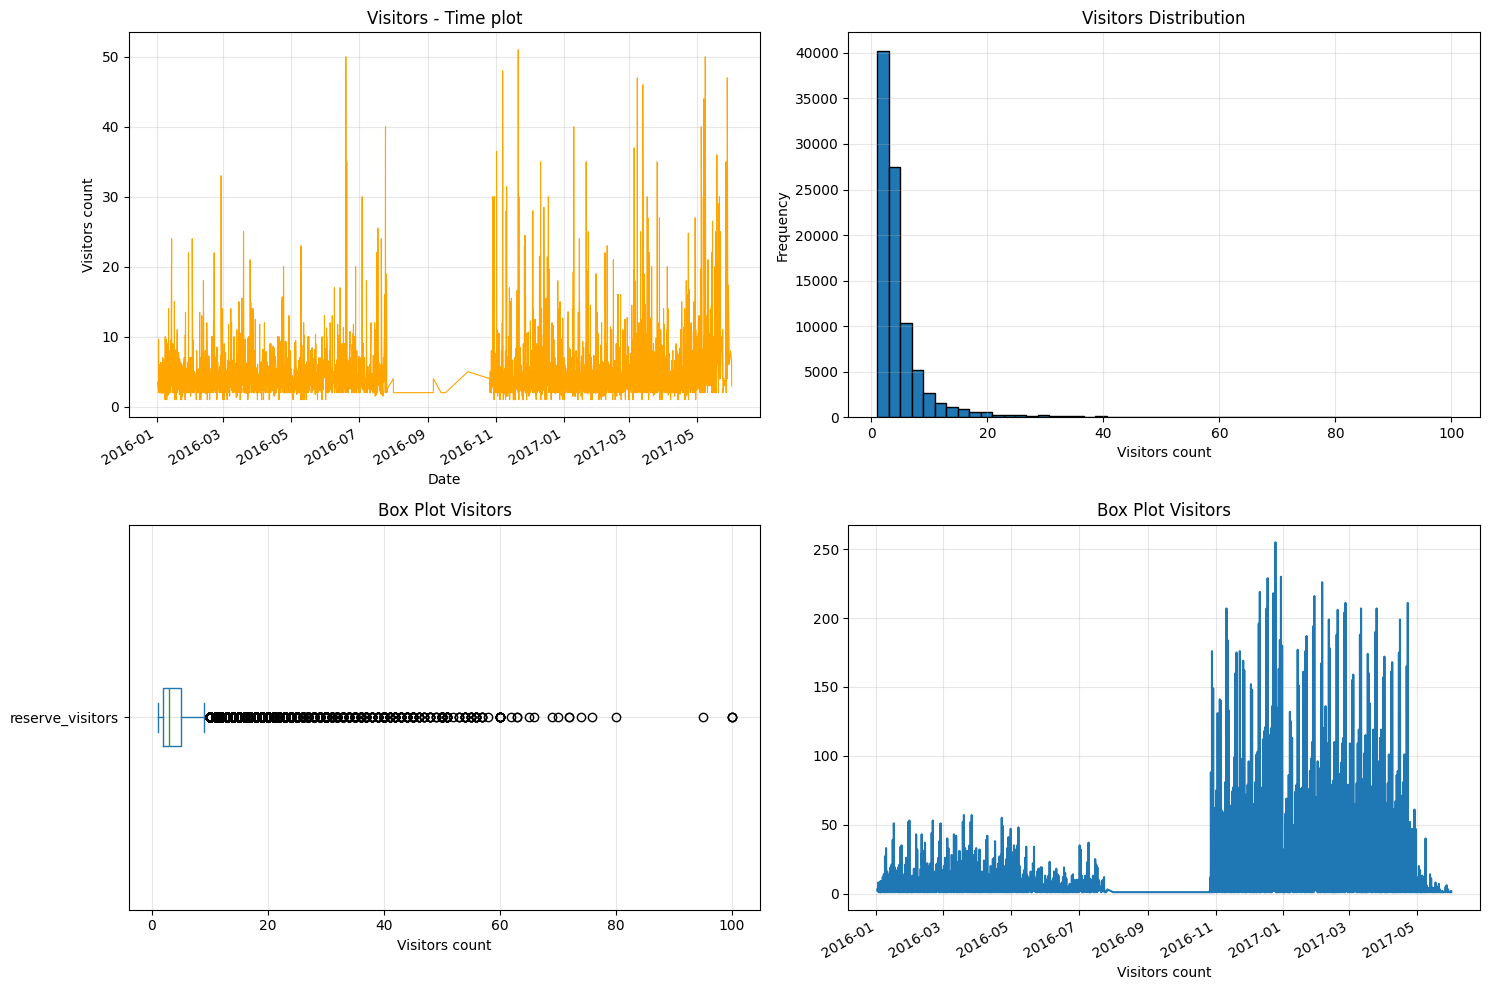

In [277]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
air_reserve_df.groupby("visit_datetime")["reserve_visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Visitors - Time plot")
plt.xlabel("Date")
plt.ylabel("Visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
air_reserve_df["reserve_visitors"].hist(bins=50, edgecolor="black")
plt.title("Visitors Distribution")
plt.xlabel("Visitors count")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
air_reserve_df["reserve_visitors"].plot(kind="box", vert=False)
plt.title("Box Plot Visitors")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
air_reserve_df.groupby("visit_datetime")["reserve_visitors"].count().plot()
plt.title("Box Plot Visitors")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

Firstly, there are a lot of outliers in the data. Secondly, there was a certain period of time during which no bookings were made for the given dates, after which the number increased sharply.

### Air visit df

It is necessary to consider the distribution of visitors for the date, the distribution of visitors for each restaurant, and outliers.

In [220]:
air_visit_df = air_visit_df.set_index("visit_date")

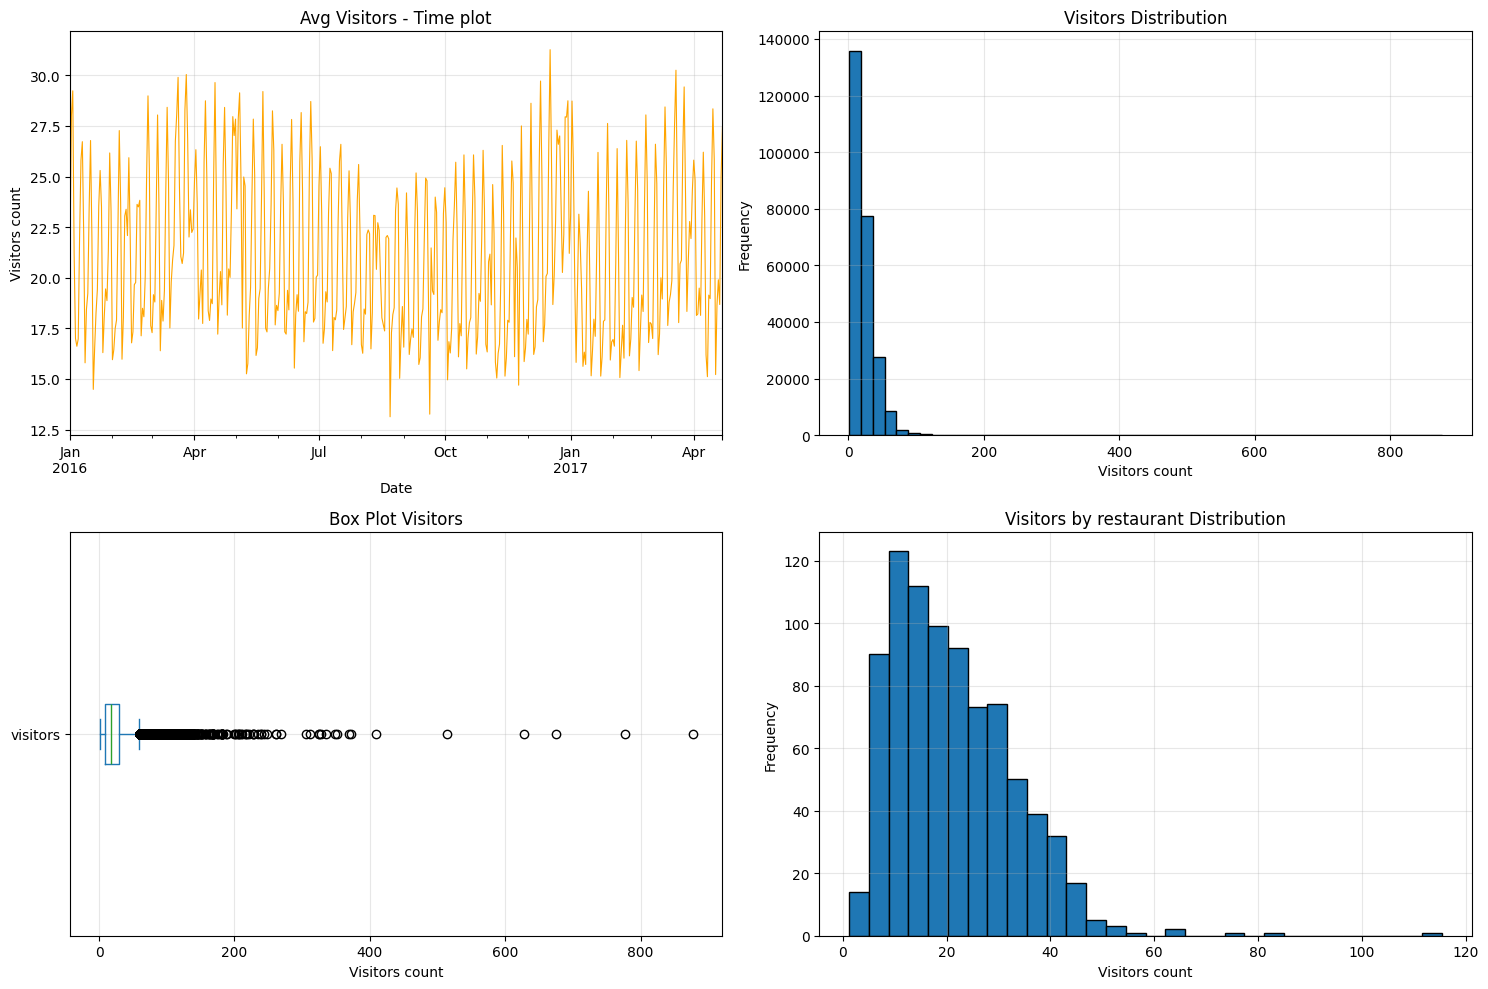

In [272]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
air_visit_df.groupby("visit_date")["visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Avg Visitors - Time plot")
plt.xlabel("Date")
plt.ylabel("Visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
air_visit_df["visitors"].hist(bins=50, edgecolor="black")
plt.title("Visitors Distribution")
plt.xlabel("Visitors count")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
air_visit_df["visitors"].plot(kind="box", vert=False)
plt.title("Box Plot Visitors")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
air_visit_df.groupby("air_store_id")["visitors"].mean().hist(bins=30, edgecolor="black")
plt.title("Visitors by restaurant Distribution")
plt.xlabel("Visitors count")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

There are quite a few outliers in the data. Moreover, the outliers are much larger than the mean (the maximum 800 is 40 times larger). There is also some periodicity in the data. This will be discussed in more detail later. There are outlier restaurants where the average number of visitors is quite large.

### Hpg reserve

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited).

In [278]:
hpg_reserve_df = hpg_reserve_df.set_index("visit_datetime")

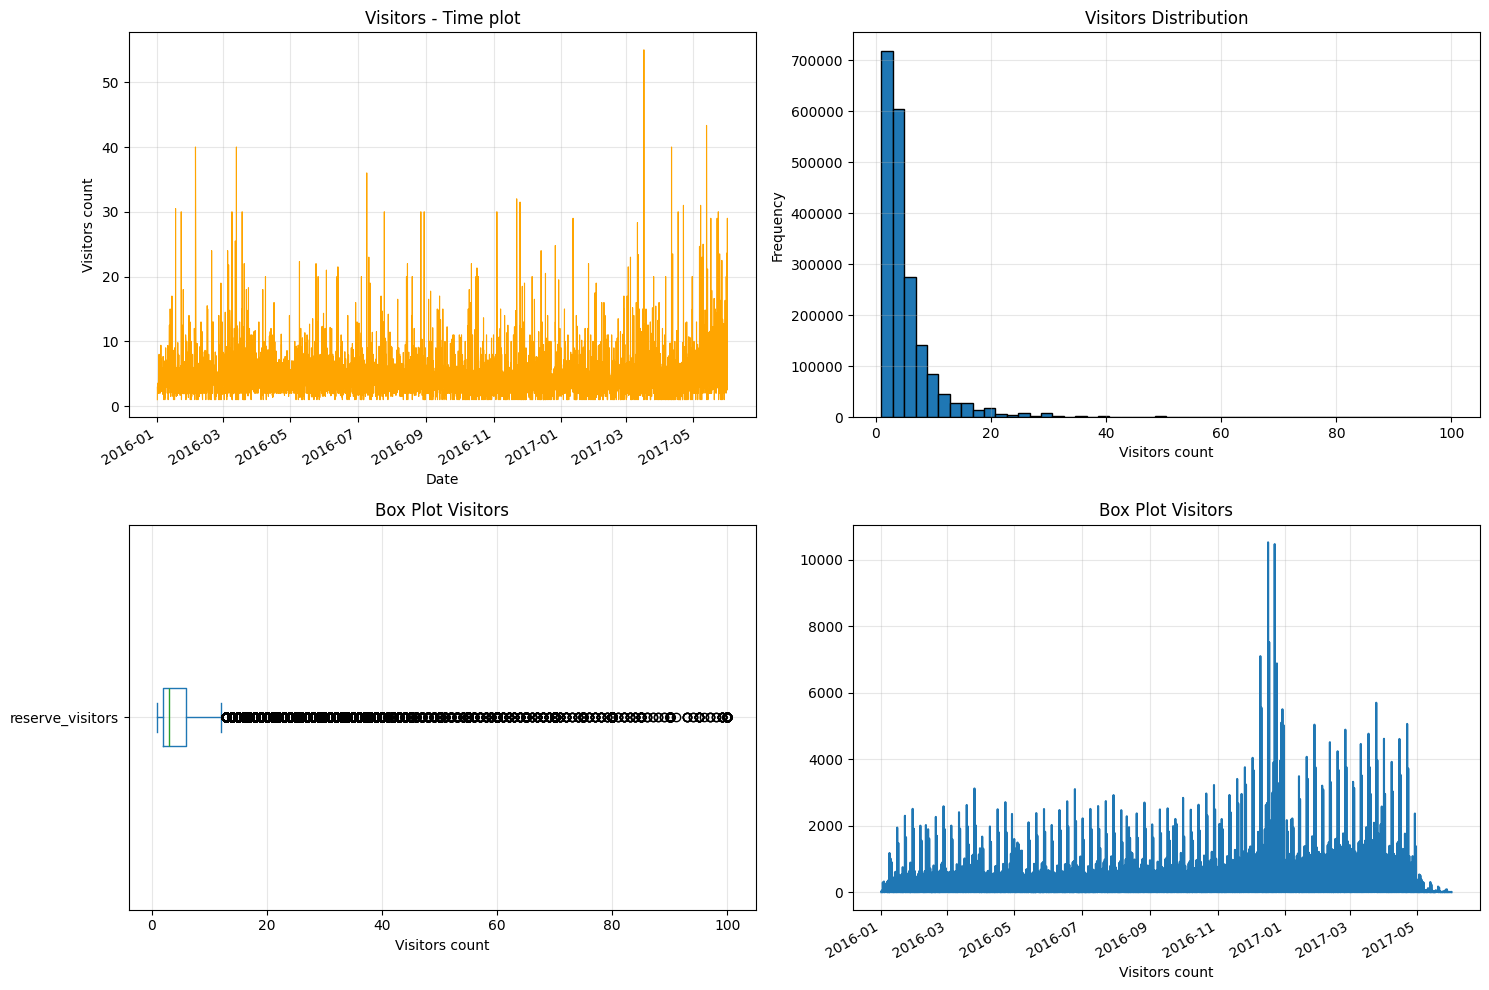

In [279]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
hpg_reserve_df.groupby("visit_datetime")["reserve_visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Visitors - Time plot")
plt.xlabel("Date")
plt.ylabel("Visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
hpg_reserve_df["reserve_visitors"].hist(bins=50, edgecolor="black")
plt.title("Visitors Distribution")
plt.xlabel("Visitors count")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
hpg_reserve_df["reserve_visitors"].plot(kind="box", vert=False)
plt.title("Box Plot Visitors")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
hpg_reserve_df.groupby("visit_datetime")["reserve_visitors"].count().plot()
plt.title("Box Plot Visitors")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The box plot shows a significant number of outliers, mostly on the higher side (visitors). The graph of bookings by visit date shows some regularity, but January 2017 shows a significant jump in bookings. Towards the end, the number of bookings becomes small, since the maximum reserve_datetime is one month less than the maximum visit_datetime, and, presumably, most bookings occur for a shorter period.

## Seasonal plots

### Hpg reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

### Air reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

### Air visit data

In [253]:
min_date = air_visit_df.index.min()
max_allowed_date = min_date + pd.DateOffset(months=3)

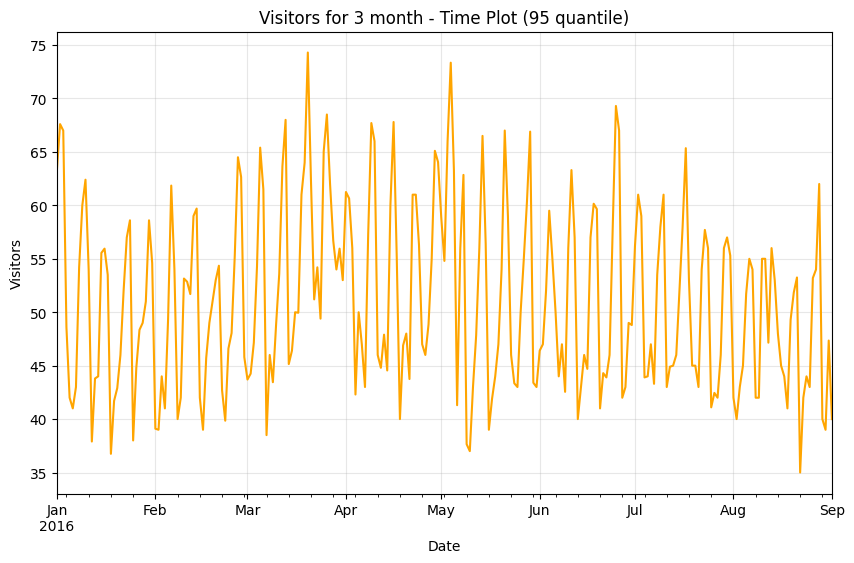

In [254]:
air_visit_df.loc[(air_visit_df.index <= max_allowed_date)].groupby("visit_date")["visitors"].quantile(0.95).plot(title="Visitors for 3 month - Time Plot (95 quantile)", figsize = (10, 6), color="orange")

plt.ylabel("Visitors")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.show()

We see a periodicity on the graph. It"s most likely related to the weekend.

In [280]:
air_visit_df["year"] = [x for x in air_visit_df.index.year]
air_visit_df["month"] = [x for x in air_visit_df.index.month]
air_visit_df = air_visit_df.reset_index()
air_visit_df["week"] = air_visit_df["visit_date"].apply(lambda x:x.week)
air_visit_df = air_visit_df.set_index("visit_date")
air_visit_df["day"] = [x for x in air_visit_df.index.day_of_week]
air_visit_df["day_str"] = [x.strftime("%a") for x in air_visit_df.index]
air_visit_df["year_month"] = [str(x.year) + "_" + str(x.month) for x in air_visit_df.index]

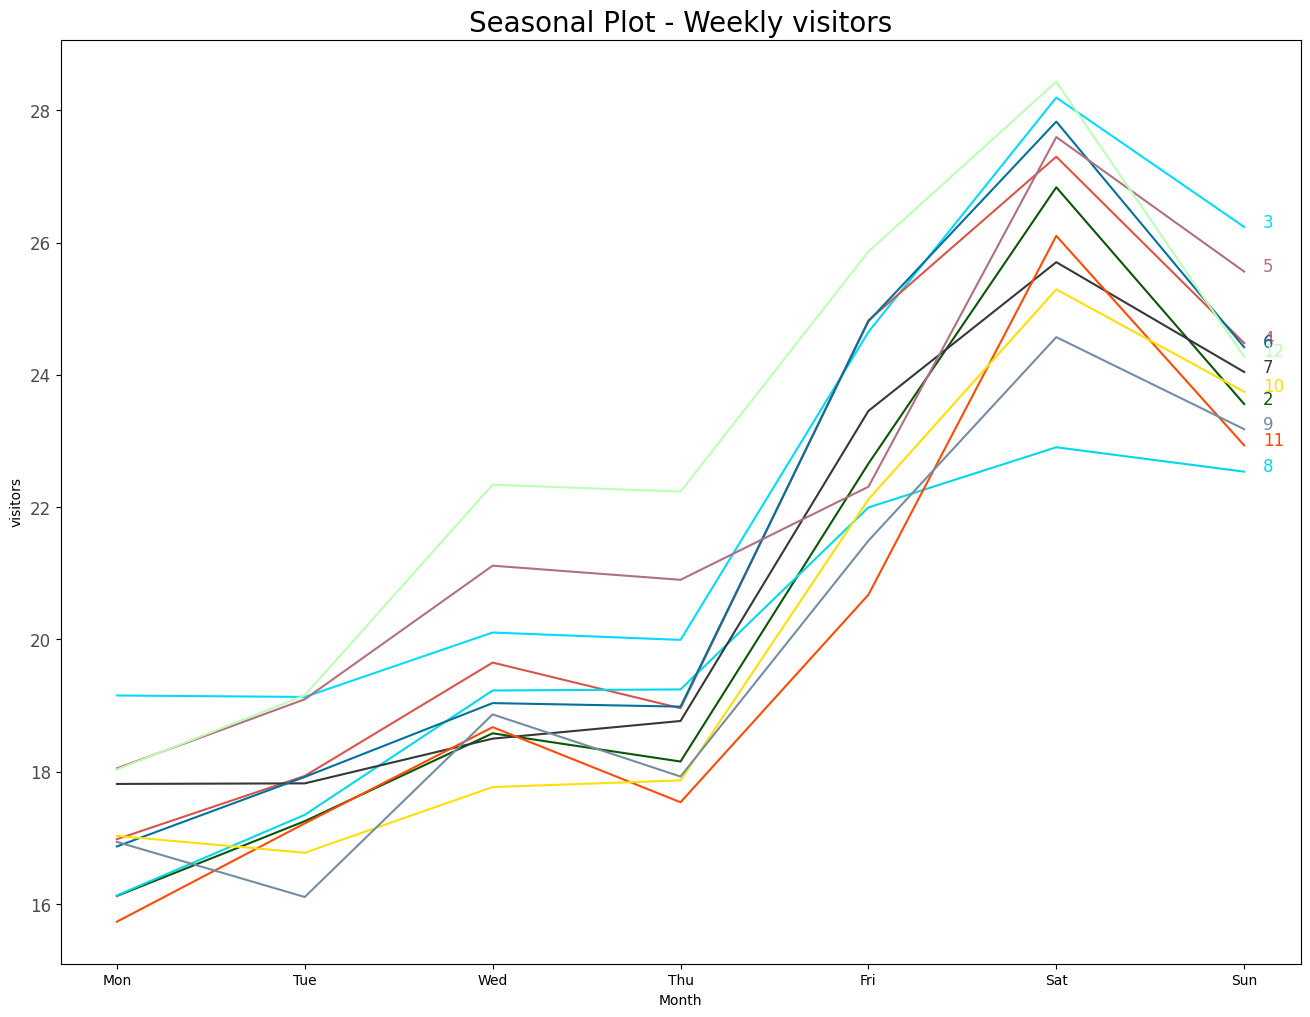

In [281]:
df_plot = (
    air_visit_df[["month", "day_str", "visitors", "day"]]
    .dropna()
    .groupby(["day_str", "month", "day"])
    .mean()[["visitors"]]
    .reset_index()
)
df_plot = df_plot.sort_values(by="day", ascending=True)

months = df_plot["month"].unique()
colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(months), replace=False)

plt.figure(figsize=(16,12))
for i, y in enumerate(months):
    if i > 0:
        plt.plot("day_str", "visitors", data=df_plot[df_plot["month"] == y], color=colors[i], label=y)
        plt.text(df_plot.loc[df_plot.month==y, :].shape[0]-.9, df_plot.loc[df_plot.month==y, "visitors"][-1:].values[0], y, fontsize=12, color=colors[i])

plt.gca().set(ylabel= "visitors", xlabel = "Month")
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot - Weekly visitors", fontsize=20)
plt.show()

The busiest hours are Friday through Sunday (and especially Saturday). There"s some slight fluctuation by month, but the trend remains consistent.

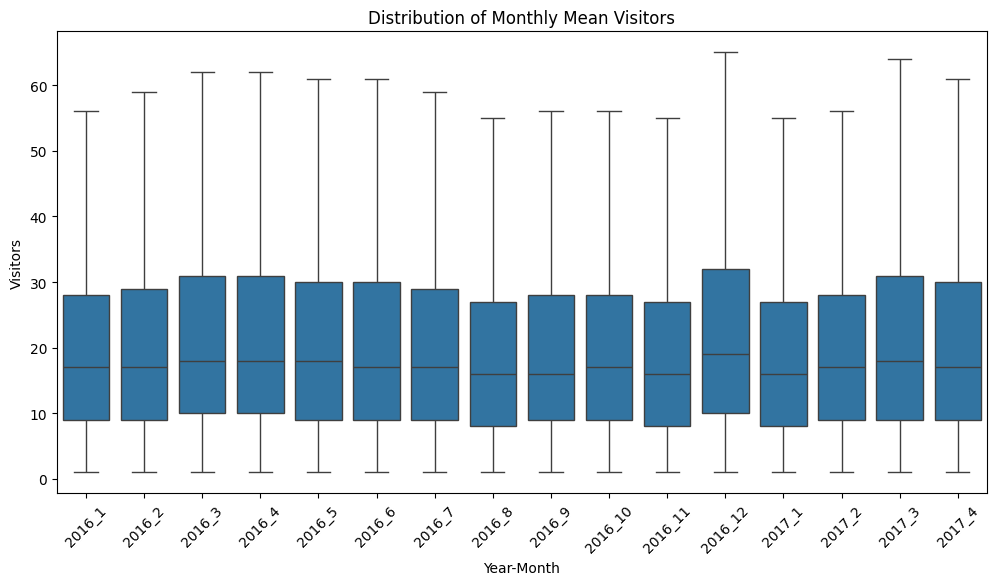

In [292]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='year_month', y='visitors', data=air_visit_df, showfliers=False)
plt.title('Distribution of Monthly Mean Visitors')
plt.xlabel('Year-Month')
plt.ylabel('Visitors')
plt.xticks(rotation=45)
plt.show()

The graph shows that the monthly average remains virtually unchanged.

### Data Correlation

It is necessary to investigate the dependence of visits on the day of the week, on holidays, on the next day (holiday, weekend or working day), on the area to which the store belongs, on the genre. Visitors on some holiday by genre.